# Baseline Models

This notebook compares three simple forecasts: demand from 30 minutes earlier, the same time yesterday and the same time last week. I select the best baseline using validation RMSE. AEMO's `FORECASTDEMAND` is evaluated separately.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load the same dataset used by the other models

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

DATA_PATH = Path('/content/drive/My Drive/NSW_Electricity_Demand/Data/Processed/Data.parquet')
OUTPUT_DIR = Path('/content/drive/My Drive/NSW_Electricity_Demand/Model Outputs/Baseline')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
df['DATETIME'] = pd.to_datetime(df['DATETIME'])
df['TOTALDEMAND'] = pd.to_numeric(df['TOTALDEMAND'], errors='coerce')
df['FORECASTDEMAND'] = pd.to_numeric(df['FORECASTDEMAND'], errors='coerce')
df = df.sort_values('DATETIME').reset_index(drop=True)

print('Rows:', f'{len(df):,}')
print('Period:', df['DATETIME'].min(), 'to', df['DATETIME'].max())

Rows: 196,417
Period: 2010-01-03 00:00:00 to 2021-03-18 00:00:00


## 2. Create baseline predictions

In [3]:
# Previous 30-minute demand
df['Baseline_Persistence'] = df['TOTALDEMAND'].shift(1)

# Same half-hour yesterday
df['Baseline_Daily'] = df['TOTALDEMAND'].shift(48)

# Same half-hour last week
df['Baseline_Weekly'] = df['TOTALDEMAND'].shift(336)

## 3. Apply the chronological split

In [4]:
n = len(df)
test_n = int(0.20 * n)
val_n = int(0.10 * n)

train_end = n - val_n - test_n
val_end = n - test_n

df_train = df.iloc[:train_end].copy()
df_val = df.iloc[train_end:val_end].copy()
df_test = df.iloc[val_end:].copy()

print('Training rows:', f'{len(df_train):,}')
print('Validation rows:', f'{len(df_val):,}')
print('Test rows:', f'{len(df_test):,}')

Training rows: 137,493
Validation rows: 19,641
Test rows: 39,283


In [5]:
STEPS = 48

train_aligned = df_train.iloc[STEPS:].copy()
validation_aligned = df_val.iloc[STEPS:].copy()
test_aligned = df_test.iloc[STEPS:].copy()

print('Aligned training targets:', f'{len(train_aligned):,}')
print('Aligned validation targets:', f'{len(validation_aligned):,}')
print('Aligned test targets:', f'{len(test_aligned):,}')
print('First test prediction:', test_aligned['DATETIME'].iloc[0])

Aligned training targets: 137,445
Aligned validation targets: 19,593
Aligned test targets: 39,235
First test prediction: 2018-12-21 15:00:00


## 5. Evaluation function

In [6]:
def evaluate_forecast(actual, predicted, model_name):
    actual = pd.Series(actual, dtype='float64').reset_index(drop=True)
    predicted = pd.Series(predicted, dtype='float64').reset_index(drop=True)

    valid = actual.notna() & predicted.notna()
    y_true = actual[valid]
    y_pred = predicted[valid]

    errors = y_pred - y_true
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = (np.abs(errors) / y_true).mean() * 100
    r2 = r2_score(y_true, y_pred)
    bias = errors.mean()

    return {
        'Model': model_name,
        'Observations': len(y_true),
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2,
        'Bias': bias,
    }

## 6. Select the best baseline using validation RMSE

In [7]:
baseline_columns = {
    'Persistence Baseline': 'Baseline_Persistence',
    'Daily Seasonal Baseline': 'Baseline_Daily',
    'Weekly Seasonal Baseline': 'Baseline_Weekly',
}

validation_results = []

for model_name, prediction_column in baseline_columns.items():
    validation_results.append(
        evaluate_forecast(
            validation_aligned['TOTALDEMAND'],
            validation_aligned[prediction_column],
            model_name,
        )
    )

validation_results = (
    pd.DataFrame(validation_results)
    .sort_values('RMSE')
    .reset_index(drop=True)
)

display(validation_results.round({
    'MAE': 2, 'RMSE': 2, 'MAPE': 2, 'R2': 4, 'Bias': 2
}))

,Model,Observations,MAE,RMSE,MAPE,R2,Bias
0,Persistence Baseline,19593,164.24,212.77,2.06,0.9680,-0.15
1,Daily Seasonal Baseline,19593,434.52,630.00,5.35,0.7192,-1.98
2,Weekly Seasonal Baseline,19593,526.58,817.30,6.40,0.5274,-14.05


In [8]:
best_baseline_name = validation_results.iloc[0]['Model']
best_baseline_column = baseline_columns[best_baseline_name]

print('Selected baseline:', best_baseline_name)

Selected baseline: Persistence Baseline


## 7. Evaluate the baselines and AEMO on the test period

In [9]:
test_results = []

for model_name, prediction_column in baseline_columns.items():
    test_results.append(
        evaluate_forecast(
            test_aligned['TOTALDEMAND'],
            test_aligned[prediction_column],
            model_name,
        )
    )

test_results.append(
    evaluate_forecast(
        test_aligned['TOTALDEMAND'],
        test_aligned['FORECASTDEMAND'],
        'AEMO Forecast',
    )
)

test_results = (
    pd.DataFrame(test_results)
    .sort_values('RMSE')
    .reset_index(drop=True)
)

display(test_results.round({
    'MAE': 2, 'RMSE': 2, 'MAPE': 2, 'R2': 4, 'Bias': 2
}))

,Model,Observations,MAE,RMSE,MAPE,R2,Bias
0,AEMO Forecast,39235,50.89,68.77,0.65,0.9970,14.47
1,Persistence Baseline,39235,168.52,214.74,2.13,0.9706,0.03
2,Daily Seasonal Baseline,39235,466.46,694.66,5.87,0.6925,1.11
3,Weekly Seasonal Baseline,39235,568.53,857.54,7.05,0.5314,6.15


## 8. Save timestamp-level predictions

In [10]:
baseline_predictions = test_aligned[[
    'DATETIME',
    'TOTALDEMAND',
    'FORECASTDEMAND',
    'Baseline_Persistence',
    'Baseline_Daily',
    'Baseline_Weekly',
]].copy()

baseline_predictions['SelectedBaseline'] = (
    baseline_predictions[best_baseline_column]
)
baseline_predictions['SelectedBaselineName'] = best_baseline_name

display(baseline_predictions.head())

,DATETIME,TOTALDEMAND,FORECASTDEMAND,Baseline_Persistence,Baseline_Daily,Baseline_Weekly,SelectedBaseline,SelectedBaselineName
157182,2018-12-21 15:00:00,8181.13,8106.42,8126.87,10980.05,8646.28,8126.87,Persistence Baseline
157183,2018-12-21 15:30:00,8257.27,8233.78,8181.13,11315.99,8586.45,8181.13,Persistence Baseline
157184,2018-12-21 16:00:00,8295.79,8249.75,8257.27,11151.86,8695.71,8257.27,Persistence Baseline
157185,2018-12-21 16:30:00,8325.49,8284.33,8295.79,10979.39,8659.02,8295.79,Persistence Baseline
157186,2018-12-21 17:00:00,8336.83,8324.81,8325.49,11120.79,8485.86,8325.49,Persistence Baseline


In [11]:
validation_results.to_csv(
    OUTPUT_DIR / 'baseline_validation_metrics.csv', index=False
)
test_results.to_csv(
    OUTPUT_DIR / 'baseline_test_metrics.csv', index=False
)
baseline_predictions.to_parquet(
    OUTPUT_DIR / 'baseline_predictions.parquet', index=False
)

print('Saved outputs to:', OUTPUT_DIR)
print('Saved prediction rows:', f'{len(baseline_predictions):,}')

Saved outputs to: /content/drive/My Drive/NSW_Electricity_Demand/Model Outputs/Baseline
Saved prediction rows: 39,235


## 9. Plot the selected baseline and AEMO forecast

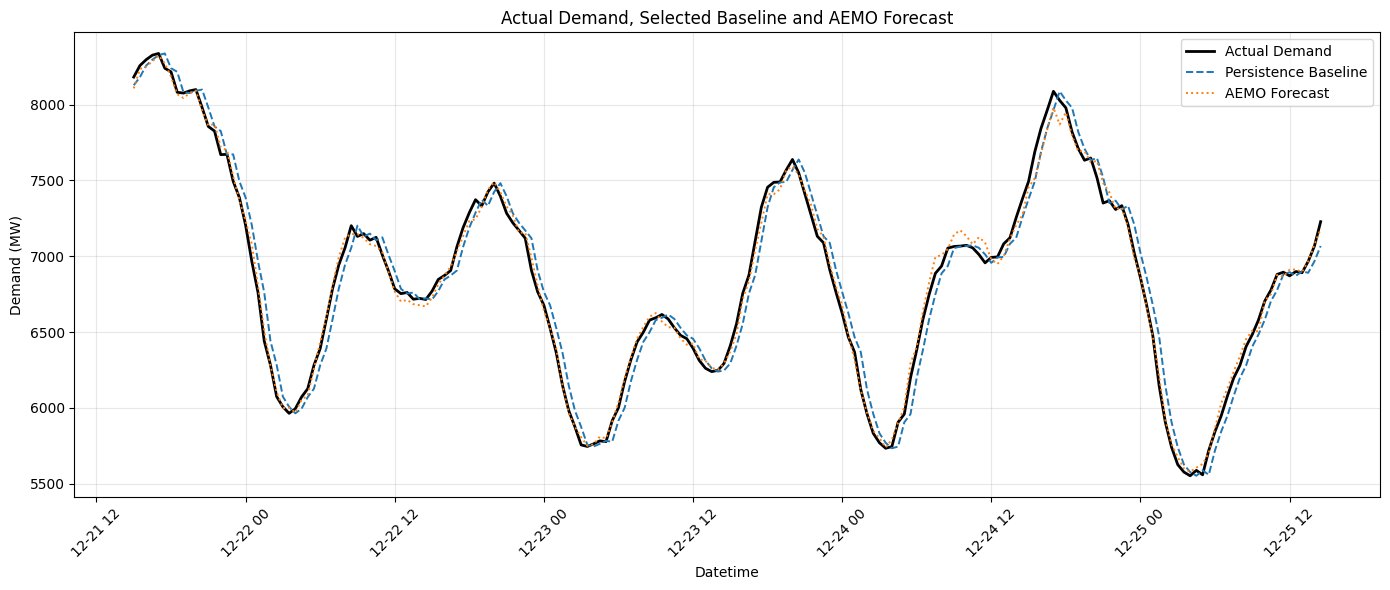

In [14]:
plot_data = baseline_predictions.iloc[:48 * 4]

plt.figure(figsize=(14, 6))
plt.plot(
    plot_data['DATETIME'], plot_data['TOTALDEMAND'],
    label='Actual Demand', color='black', linewidth=2
)
plt.plot(
    plot_data['DATETIME'], plot_data['SelectedBaseline'],
    label=best_baseline_name, linestyle='--', linewidth=1.4
)
plt.plot(
    plot_data['DATETIME'], plot_data['FORECASTDEMAND'],
    label='AEMO Forecast', linestyle=':', linewidth=1.4
)
plt.title('Actual Demand, Selected Baseline and AEMO Forecast')
plt.xlabel('Datetime')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The validation table determines which simple baseline is selected. The test table is a check for this notebook; the final project comparison will recalculate all model metrics from the saved timestamp-level prediction files.